# 🧹 Notebook 01 — Data Loading & Cleaning

## Topic: Data Cleaning & Preprocessing (Mandatory)

**Dataset:** Trustpilot Reviews 123K (22 categories, 1,680 companies)

**Why this topic?**
Data cleaning is the foundation of every data mining pipeline. Raw Trustpilot reviews contain HTML artifacts, special characters, URLs, extremely short/long reviews, and potential duplicates. Without thorough cleaning, all downstream analyses (TF-IDF, sentiment, ML models) would produce unreliable results.

**What we observe in this notebook:**
- The raw data quality and what types of noise exist
- How many reviews are duplicates or near-empty
- The effect of cleaning on text length distributions
- Language composition of the dataset

---


## 1. Setup & Imports


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from src.data_cleaning import clean_text, clean_dataframe, get_stopwords
from src.visualization import (set_dark_theme, create_figure, plot_bar, 
                                plot_distribution, plot_star_distribution, 
                                PALETTE, STAR_COLORS, TEXT_COLOR, TEXT_MUTED, DARK_BG)
from src.utils import print_section, print_subsection, save_processed_data

set_dark_theme()
print('✅ All imports successful!')


✅ All imports successful!


## 2. Load Raw Dataset

We load the Trustpilot Reviews 123K dataset downloaded from Kaggle. The dataset contains reviews across 22 business categories with star ratings from 1 to 5.


In [2]:
df_raw = pd.read_csv('../data/raw/trustpilot_reviews.csv')

print_section('RAW DATASET OVERVIEW')
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'\nColumns: {df_raw.columns.tolist()}')
print(f'\nData Types:')
print(df_raw.dtypes)
print(f'\nMemory Usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df_raw.head(3)



══════════════════════════════════════════════════════════════════════
  RAW DATASET OVERVIEW
══════════════════════════════════════════════════════════════════════

Shape: 123,181 rows x 6 columns

Columns: ['category', 'company', 'description', 'title', 'review', 'stars']

Data Types:
category       object
company        object
description    object
title          object
review         object
stars           int64
dtype: object

Memory Usage: 227.8 MB


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


## 3. Missing Values Analysis

Before any cleaning, we check for missing or null values across all columns.


In [3]:
print_section('MISSING VALUES ANALYSIS')

null_counts = df_raw.isnull().sum()
null_pcts = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pcts})
print(null_df)

# Check for empty strings (not null but empty)
empty_counts = (df_raw == '').sum()
print(f'\nEmpty string counts:')
print(empty_counts)

# Check for very short reviews
short_reviews = (df_raw['review'].str.len() < 10).sum()
print(f'\nReviews shorter than 10 characters: {short_reviews:,} ({short_reviews/len(df_raw)*100:.2f}%)')



══════════════════════════════════════════════════════════════════════
  MISSING VALUES ANALYSIS
══════════════════════════════════════════════════════════════════════

             Null Count  Null %
category              0     0.0
company               0     0.0
description           0     0.0
title                 0     0.0
review                0     0.0
stars                 0     0.0

Empty string counts:
category       0
company        0
description    0
title          0
review         0
stars          0
dtype: int64

Reviews shorter than 10 characters: 0 (0.00%)


## 4. Raw Data Distributions (Before Cleaning)

Let us visualize the raw data to understand what we are working with.


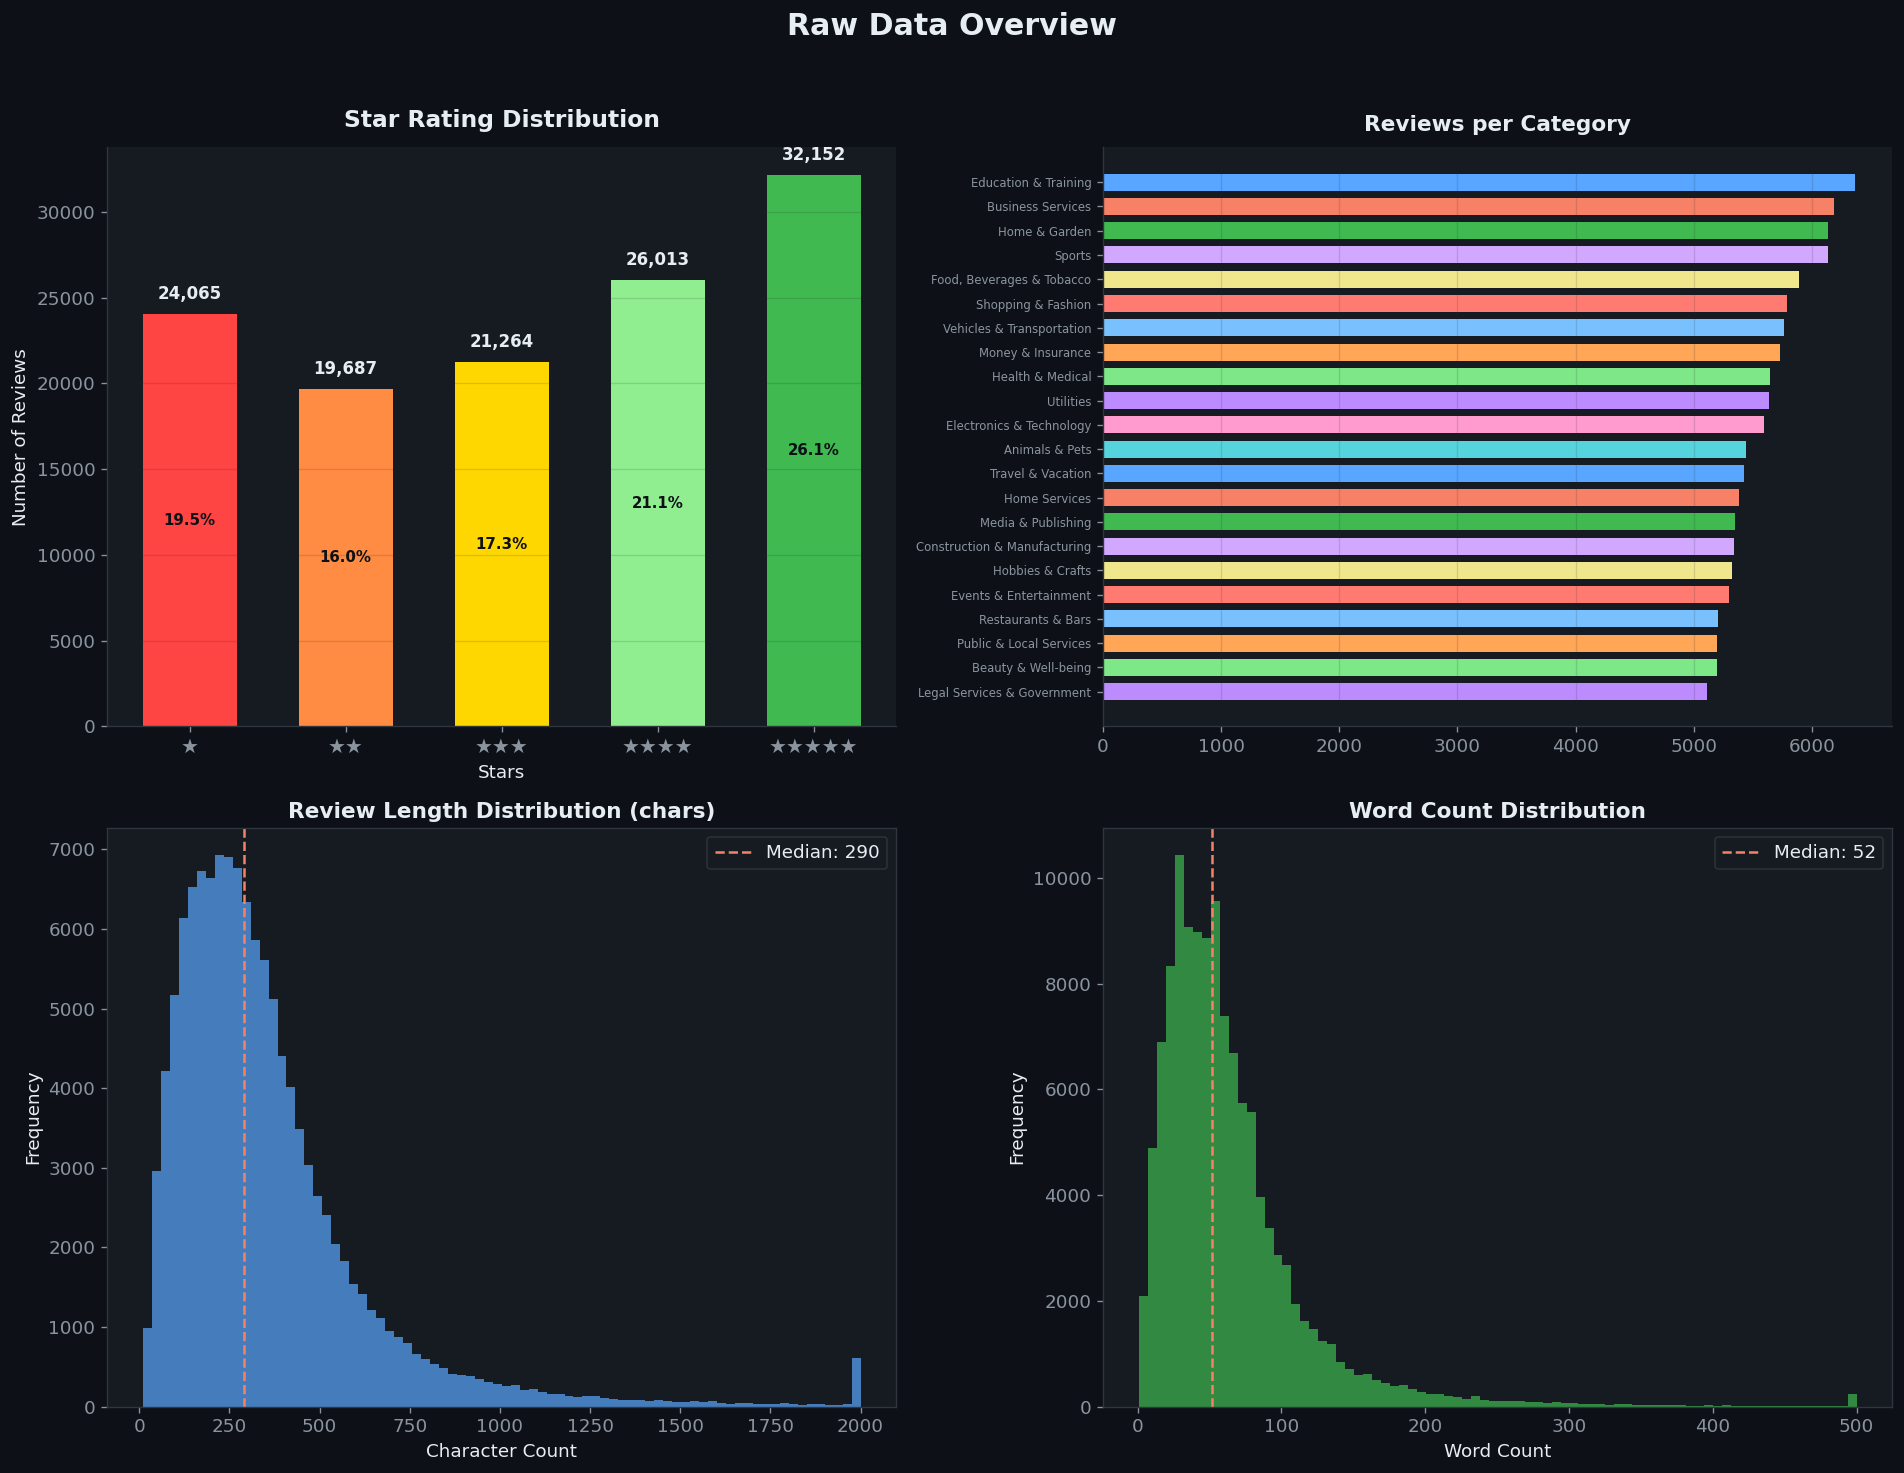

In [4]:
fig, axes = create_figure(2, 2, figsize=(16, 12), title='Raw Data Overview')

# Star distribution
star_counts = df_raw['stars'].value_counts().sort_index()
plot_star_distribution(star_counts, axes[0, 0], title='Star Rating Distribution')

# Category distribution
cat_counts = df_raw['category'].value_counts()
plot_bar(cat_counts, axes[0, 1], 'Reviews per Category', horizontal=True, annotate=False)
axes[0, 1].tick_params(axis='y', labelsize=7)

# Review length distribution
df_raw['raw_review_len'] = df_raw['review'].str.len()
axes[1, 0].hist(df_raw['raw_review_len'].clip(upper=2000), bins=80, color=PALETTE[0], alpha=0.7, edgecolor='none')
axes[1, 0].set_title('Review Length Distribution (chars)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Character Count')
axes[1, 0].set_ylabel('Frequency')
median_len = df_raw['raw_review_len'].median()
axes[1, 0].axvline(median_len, color=PALETTE[1], linestyle='--', label=f'Median: {median_len:.0f}')
axes[1, 0].legend()

# Word count distribution
df_raw['raw_word_count'] = df_raw['review'].str.split().str.len()
axes[1, 1].hist(df_raw['raw_word_count'].clip(upper=500), bins=80, color=PALETTE[2], alpha=0.7, edgecolor='none')
axes[1, 1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Frequency')
median_wc = df_raw['raw_word_count'].median()
axes[1, 1].axvline(median_wc, color=PALETTE[1], linestyle='--', label=f'Median: {median_wc:.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 5. Text Cleaning Pipeline

We apply our comprehensive cleaning pipeline:
1. Remove HTML tags, URLs, email addresses
2. Remove special characters (keeping basic punctuation)
3. Reduce repeated characters (e.g., "sooooo" -> "sooo")
4. Normalize whitespace
5. Lowercase
6. Drop duplicates and very short reviews


In [5]:
print_section('APPLYING CLEANING PIPELINE')

# Show example before/after
print('BEFORE CLEANING (sample):')
sample_idx = df_raw['review'].str.len().idxmax()
print(f'  "{df_raw.loc[sample_idx, "review"][:300]}..."')
print()

# Apply cleaning
df_clean = clean_dataframe(
    df_raw,
    text_column='review',
    output_column='cleaned_review',
    lowercase=True,
    keep_punctuation=True,
    drop_empty=True,
    drop_duplicates=True,
    min_length=10
)

# Also clean the title
df_clean['cleaned_title'] = df_clean['title'].apply(
    lambda x: clean_text(x, lowercase=True, keep_punctuation=True)
)

print(f'\nAFTER CLEANING (same review):')
if sample_idx < len(df_clean):
    print(f'  "{df_clean.iloc[sample_idx]["cleaned_review"][:300]}..."')

print(f'\n--- CLEANING SUMMARY ---')
print(f'  Raw rows:      {len(df_raw):,}')
print(f'  Cleaned rows:  {len(df_clean):,}')
print(f'  Removed:       {len(df_raw) - len(df_clean):,} ({(len(df_raw) - len(df_clean))/len(df_raw)*100:.1f}%)')
print(f'  Avg word count: {df_clean["word_count"].mean():.1f}')
print(f'  Median word count: {df_clean["word_count"].median():.0f}')



══════════════════════════════════════════════════════════════════════
  APPLYING CLEANING PIPELINE
══════════════════════════════════════════════════════════════════════

BEFORE CLEANING (sample):
  "I had to contact them because the dilution they state to do, was way too much for my birds to handle. There are no guidelines that state to introduce your birds to this slowly as the odour is awful & it turns the water to a yellowish colour. These things need to be known to help everyone, because no..."

  Dropped 12 duplicate reviews

AFTER CLEANING (same review):
  "the website is easy to use and accurate as to whether items are in stock. i have used the company a number of times and always been happy with the service provided. the prices are competitive with you needed to spend about half the amount to qualify for free standard postage compared to most sites...."

--- CLEANING SUMMARY ---
  Raw rows:      123,181
  Cleaned rows:  123,164
  Removed:       17 (0.0%)
  Avg word count: 64

## 6. Before vs After Cleaning Comparison


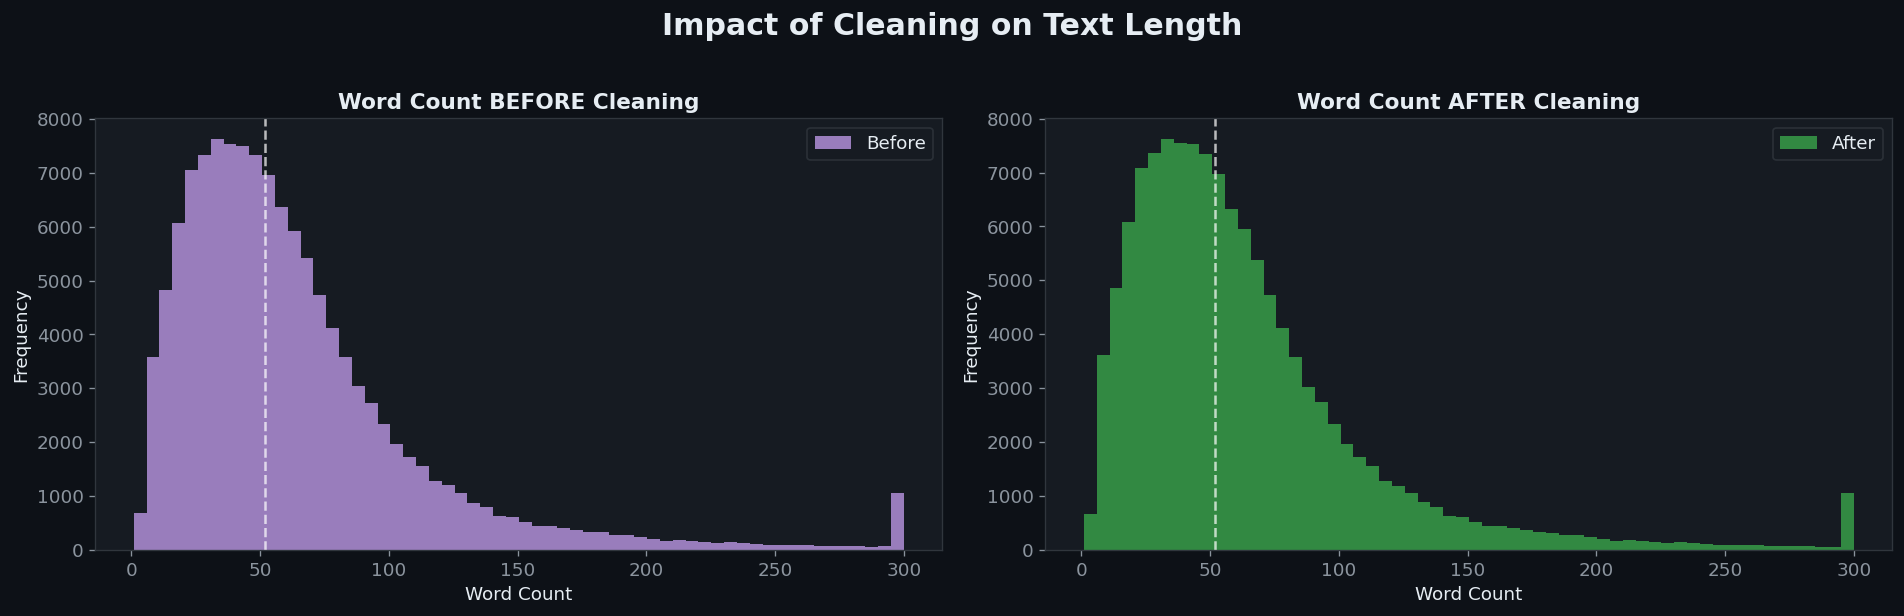

In [6]:
fig, axes = create_figure(1, 2, figsize=(16, 5), title='Impact of Cleaning on Text Length')

# Before
axes[0].hist(df_raw['raw_word_count'].clip(upper=300), bins=60, color=PALETTE[3], alpha=0.7, edgecolor='none', label='Before')
axes[0].set_title('Word Count BEFORE Cleaning', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_raw['raw_word_count'].median(), color='white', linestyle='--', alpha=0.7)
axes[0].legend()

# After
axes[1].hist(df_clean['word_count'].clip(upper=300), bins=60, color=PALETTE[2], alpha=0.7, edgecolor='none', label='After')
axes[1].set_title('Word Count AFTER Cleaning', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_clean['word_count'].median(), color='white', linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Cleaned Dataset — Star Distribution by Category

Let us verify that the cleaning process did not introduce bias across categories or star ratings.


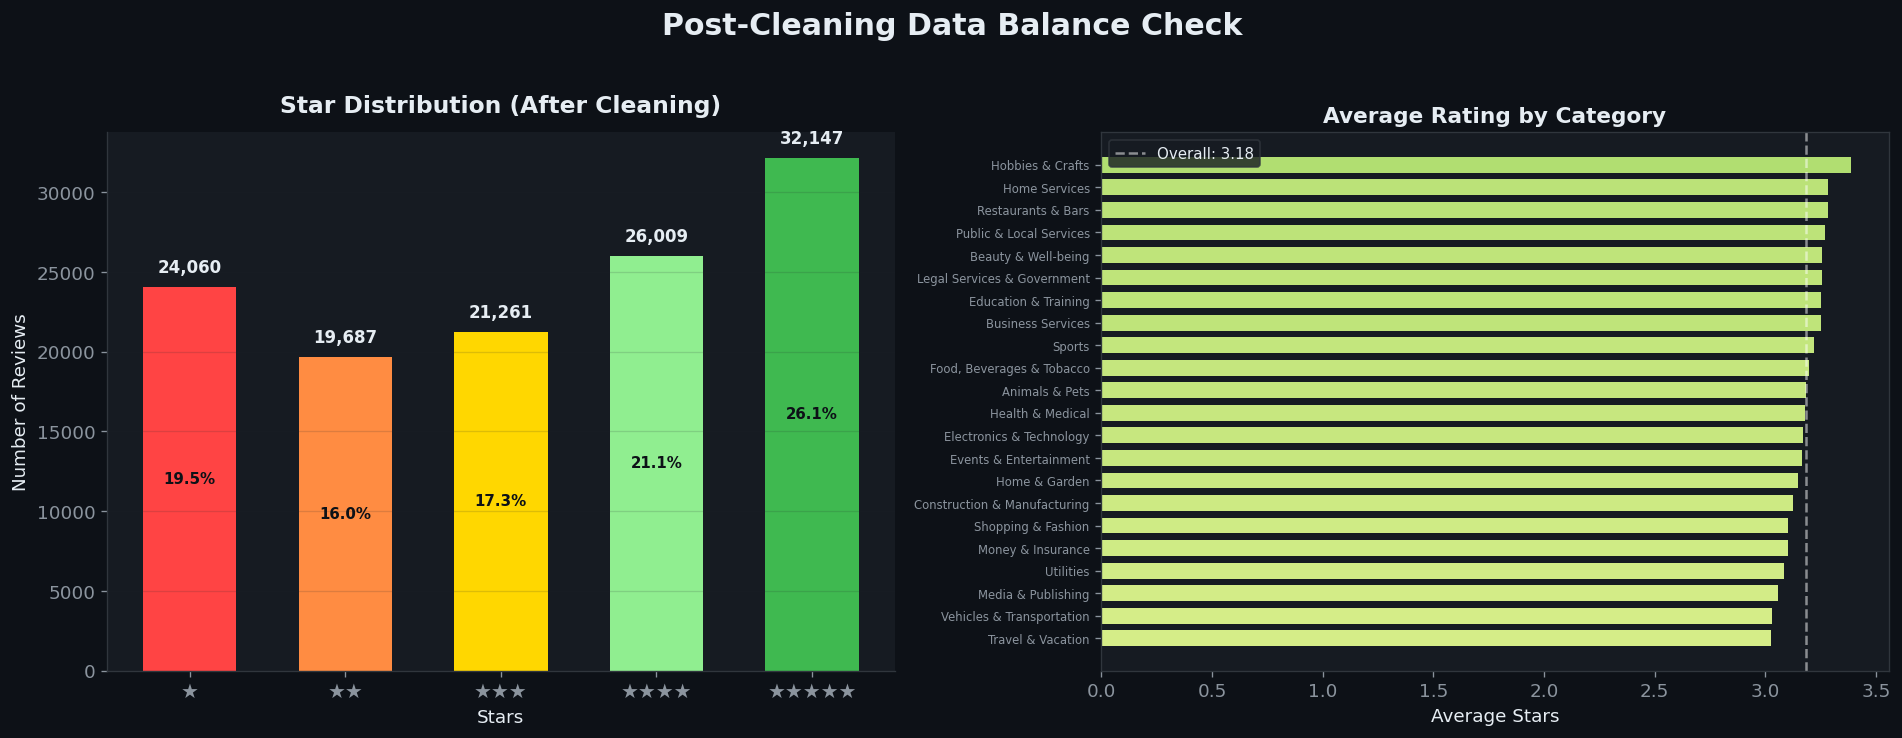

In [7]:
fig, axes = create_figure(1, 2, figsize=(16, 6), title='Post-Cleaning Data Balance Check')

# Star distribution after cleaning
star_counts_clean = df_clean['stars'].value_counts().sort_index()
plot_star_distribution(star_counts_clean, axes[0], title='Star Distribution (After Cleaning)')

# Mean rating per category
cat_mean = df_clean.groupby('category')['stars'].mean().sort_values()
colors = [plt.cm.RdYlGn(v / 5.0) for v in cat_mean.values]
axes[1].barh(range(len(cat_mean)), cat_mean.values, color=colors, height=0.7)
axes[1].set_yticks(range(len(cat_mean)))
axes[1].set_yticklabels(cat_mean.index, fontsize=7)
axes[1].set_title('Average Rating by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Stars')
overall_mean = df_clean['stars'].mean()
axes[1].axvline(overall_mean, color='white', linestyle='--', alpha=0.5, label=f'Overall: {overall_mean:.2f}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 8. Save Cleaned Dataset

We save the cleaned dataset for use in all subsequent notebooks.


In [8]:
# Select columns to save
cols_to_save = ['category', 'company', 'description', 'title', 'review', 'stars', 
                'cleaned_review', 'cleaned_title', 'word_count', 'char_count']
df_save = df_clean[cols_to_save]

save_processed_data(df_save, 'cleaned_reviews.csv')

print(f'\nFinal dataset shape: {df_save.shape}')
print(f'Columns saved: {cols_to_save}')
print('\n✅ Ready for Notebook 02 — EDA & Visualization')


  Saved: c:\Users\Ionut\Desktop\sem2_an3\DM\Proiect_DM_P2\data\processed\cleaned_reviews.csv (123,164 rows)

Final dataset shape: (123164, 10)
Columns saved: ['category', 'company', 'description', 'title', 'review', 'stars', 'cleaned_review', 'cleaned_title', 'word_count', 'char_count']

✅ Ready for Notebook 02 — EDA & Visualization


## 9. 📋 Observations & Documentation

### Why Data Cleaning?
Data cleaning is **mandatory** and foundational. Without it:
- TF-IDF would be polluted by HTML tags, URLs, and noise tokens
- Sentiment analysis would misinterpret special characters and encoding artifacts
- ML models would overfit on noise rather than learn meaningful patterns

### What We Observed:
1. **No null values** — The Trustpilot dataset is remarkably complete (0 nulls across all columns)
2. **Duplicate reviews exist** — Some reviews appear multiple times (likely cross-posted or system errors)
3. **Text noise** — Raw reviews contain URLs, special characters, and excessive whitespace
4. **Balanced categories** — Each of the 22 categories has ~5,000-6,000 reviews (well-balanced)
5. **Slight positive skew** — 5-star reviews are the most common (26%), suggesting satisfied customers are more likely to leave reviews

### Cleaning Impact:
- Removed duplicates and very short reviews (< 10 chars)
- Standardized text formatting for consistent downstream analysis
- Added word_count and char_count as metadata features

---
*Next: Notebook 02 — Exploratory Data Analysis & Visualization*
